# Instructions
- Make a copy of this notebook in your drive.
- Load the **Netflix Movies and TV Shows dataset**.
- Read through each step and run the cells in order.
- Do not skip steps; each one builds on the previous one.
- Add your own observations wherever possible, especially when exploring graphs.
- This is practice for real-world data preprocessing and EDA, so think about *why* each step is done, not just *how*.
- At the end, feel free to explore further and add more plots, groupbys, or questions of your own.

Welcome to this checkpoint task.

Today we are exploring the Netflix Movies and TV Shows dataset to practice data preprocessing and exploratory data analysis (EDA). Think of the dataset as a big streaming catalogue that needs sorting before it is ready to be recommended to viewers - we will clean it, organize it, and look for patterns worth noticing.

We will be using pandas, numpy, matplotlib, and seaborn for this task.

Run the following cell to import them.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('ggplot')

## Setting the Scene

Before analyzing anything, we need to bring the dataset into our workspace.

**Your task:**
- Load the dataset into a pandas DataFrame.
- Look at the first few rows to see what the data contains.
- Check the shape of the dataset - how many titles and how many columns are we working with?

Think of this as opening the catalogue for the first time and getting a feel for its size.

In [9]:
df = pd.read_csv('/content/sample_data/netflix_titles.csv')

In [10]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [12]:
df.shape

(8807, 12)

### Level 1: Know Your Columns

Every dataset has its own structure - some columns hold text, some hold numbers, and some may be incomplete.

**Your task:**
- Get a quick overview of column types and how many missing values each column has.
- Double-check that each column's data type makes sense for what it represents.

This is like reading the label on each shelf before you start organizing it.

In [13]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [14]:
df.dtypes

,0
show_id,object
type,object
title,object
director,object
cast,object
country,object
date_added,object
release_year,int64
rating,object
duration,object


### Level 2: Quick Stats Check

Before diving deeper, it helps to see a summary of the numerical columns.

**Your task:**
- Get summary statistics for the numerical columns.
- Note things like the earliest and most recent release years, and how the values are spread out.

This step gives you a first impression of the range and scale of the data.

In [16]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


## Level 3: Clean the Catalogue (Missing Values)

Some entries in a streaming catalogue are incomplete, and we need to decide how to handle that.

**Your tasks:**
- Check how many missing values are in each column.
- For this dataset, handle missing values in **`director`** and **`country`** by removing those rows.
- Re-check to confirm there are no missing values left in those two columns.

> Tip: Do a quick sanity check after cleaning - the row count should drop a bit.

In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
df = df.dropna(subset=['director', 'country']).reset_index(drop=True).copy()
df.shape


(5751, 12)

In [19]:
df[['director', 'country']].isna().sum()

,0
director,0
country,0


## Level 4: Fix the `date_added` Column (Data Types)

The `date_added` column is usually stored as plain text, which makes it hard to work with dates properly.

**Your tasks:**
- Convert **`date_added`** to a proper datetime type.
- Create a new column called **`year_added`** that extracts just the year from `date_added`.
- Run a quick `info()` check to confirm the changes.

> If the conversion produces errors, check for stray spaces or unexpected formats in the column first.

In [20]:
df['date_added'] = pd.to_datetime(df['date_added'].str.strip())
df['year_added'] = df['date_added'].dt.year
df.dtypes

,0
show_id,object
type,object
title,object
director,object
cast,object
country,object
date_added,datetime64[ns]
release_year,int64
rating,object
duration,object


## Level 5: The Longest Watches

Some titles run much longer than others. Let's find the standouts.

**Your task:**
- List the **Top 5 longest movies** in the dataset.
- Display their **title, country, release_year, and duration**.

Think of this as building a short list for viewers who want an epic movie night.

In [22]:
movies = df.query('type == "Movie"').copy()
movies = movies.dropna(subset=['duration'])
movies['Duration_min'] = movies['duration'].str.replace(' min', '', regex=False).astype(int)

movies.sort_values('Duration_min', ascending=False) \
    .head(5)[['title', 'country', 'release_year', 'duration']]

,title,country,release_year,duration
1413,The School of Mischief,Egypt,1973,253 min
1411,No Longer kids,Egypt,1979,237 min
75,Once Upon a Time in America,"Italy, United States",1984,229 min
5043,Sangam,India,1964,228 min
493,Lagaan,"India, United Kingdom",2001,224 min


## Level 6: Movies vs TV Shows

The catalogue contains two kinds of content: movies and TV shows.

**Your task:**
- Count how many titles fall into each `type` category.
- Create a bar chart to visualize the counts.
- Answer: which type makes up the larger share of the catalogue?

In [23]:
df['type'].value_counts()

,count
type,
Movie,5562
TV Show,189


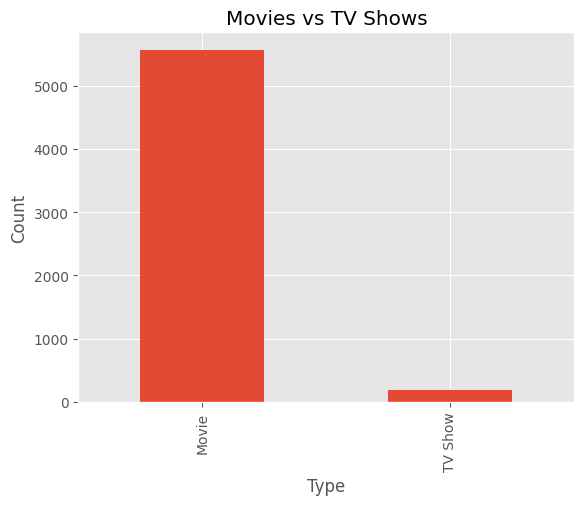

In [24]:
ax = df['type'].value_counts().plot(kind='bar', title='Movies vs TV Shows')
ax.set_xlabel('Type')
ax.set_ylabel('Count')
plt.show()

## Level 7: Where Does the Content Come From?

Netflix sources content from many countries.

**Your task:**
- Find the **Top 5 countries** with the highest number of titles.
- Show their contribution using a pie chart.

This will help us see which countries dominate the catalogue.

In [25]:
df['country'].value_counts().head(5)

,count
country,
United States,2048
India,890
United Kingdom,212
Canada,119
Spain,106


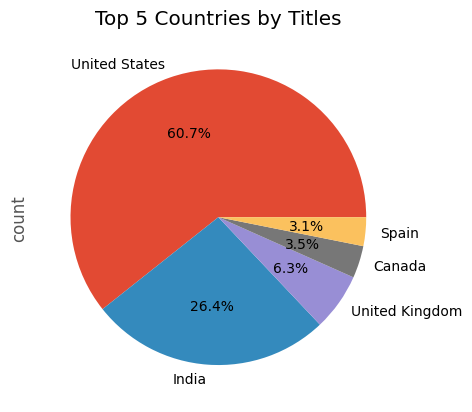

In [26]:
ax = df['country'].value_counts().head(5) \
    .plot(kind='pie', autopct='%1.1f%%', title='Top 5 Countries by Titles')
plt.show()

## Level 8: Genre Leaders by Country

Different genres may be led by different countries.

**Your task:**
- For each genre in `listed_in`, find the **country** that has produced the most titles in that genre.
- Print the results as a list (Genre -> Leading Country).

> Note: a title can belong to more than one genre - think about how you want to handle that before grouping.

In [28]:
genre_df = df.copy()
genre_df['listed_in'] = genre_df['listed_in'].str.split(',')
genre_df = genre_df.explode('listed_in')
genre_df['listed_in'] = genre_df['listed_in'].str.strip()
genre_df.shape
genre_df.groupby('listed_in')['country'].agg(lambda x: x.value_counts().idxmax())

,country
listed_in,
Action & Adventure,United States
Anime Features,Japan
Anime Series,Japan
British TV Shows,United Kingdom
Children & Family Movies,United States
Classic & Cult TV,United Kingdom
Classic Movies,United States
Comedies,United States
Crime TV Shows,United States


## Level 9: Netflix's Busiest Year

Netflix has grown its catalogue steadily over the years, but some years stand out more than others.

**Your task:**
- Group the data by `year_added`.
- Find the year in which Netflix added the **most titles** to its catalogue.

This shows us the point where the platform's library grew the fastest.

Busiest year: 2019 - 1352 titles


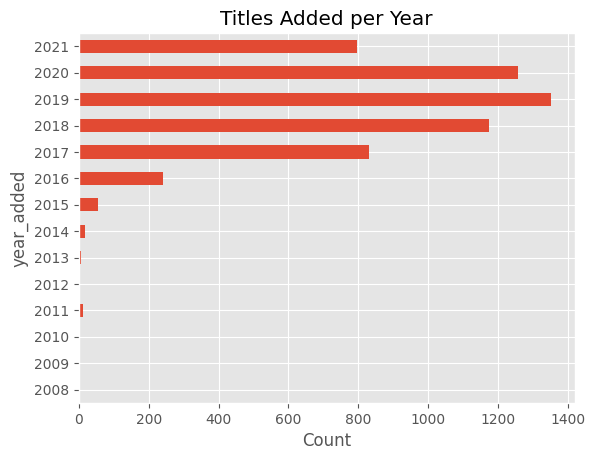

In [ ]:
busiest_year = year_counts.idxmax()
print('Busiest year:', busiest_year, '-', year_counts.max(), 'titles')

ax = year_counts.sort_index().plot(kind='barh', title='Titles Added per Year')
ax.set_xlabel('Count')
plt.show()

In [29]:
year_counts = df.groupby('year_added')['show_id'].agg('count').sort_values(ascending=False)
year_counts

,show_id
year_added,
2019,1352
2020,1256
2018,1175
2017,830
2021,797
2016,240
2015,56
2014,18
2011,13


## Final Task: Open Exploration

You have worked through each step above - now it's time to explore on your own.

**Your final task:**
- Choose any 2 to 3 plots of your own choice that reveal an interesting pattern in the data.

This is your creative zone - treat it as building your own short story from the dataset. When you are done, share your best plot and the observation behind it with the group.

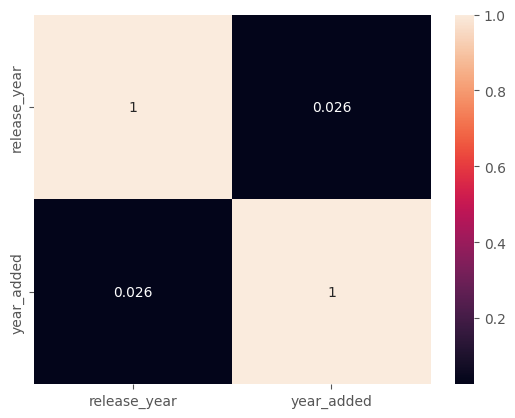

In [32]:
df_corr = df[['release_year', 'year_added']].dropna().corr()

sns.heatmap(df_corr, annot=True)
plt.show()

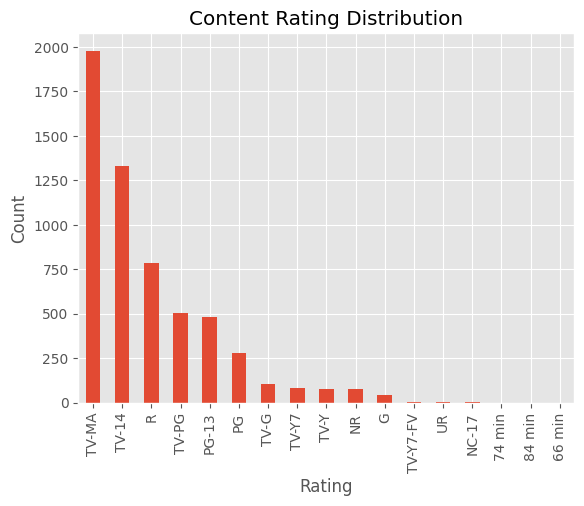

In [33]:
ax = df['rating'].value_counts().plot(kind='bar', title='Content Rating Distribution')
ax.set_xlabel('Rating')
ax.set_ylabel('Count')
plt.show()

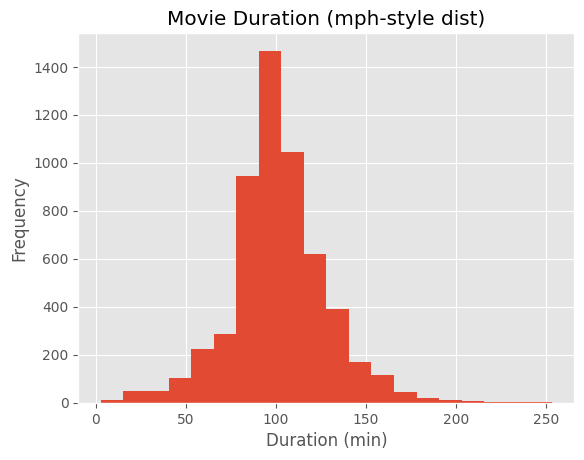

In [34]:
ax = movies['Duration_min'].plot(kind='hist', bins=20, title='Movie Duration (mph-style dist)')
ax.set_xlabel('Duration (min)')
plt.show()